<a href="https://colab.research.google.com/github/devarsh3453/NEW/blob/main/Outliars_IQR_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [18]:
df=pd.read_csv("/content/placement_outliars.csv")

In [19]:
df.sample(11)

,cgpa,placement_exam_marks,placed
25,6.28,58.0,1
984,6.89,16.0,1
456,6.76,12.0,1
623,7.35,14.0,1
925,6.91,56.0,1
441,7.80,15.0,1
335,6.90,17.0,1
34,8.15,9.0,0
243,6.78,55.0,0
503,6.97,10.0,1


In [20]:
import seaborn as sns

/tmp/ipykernel_529/2619590868.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

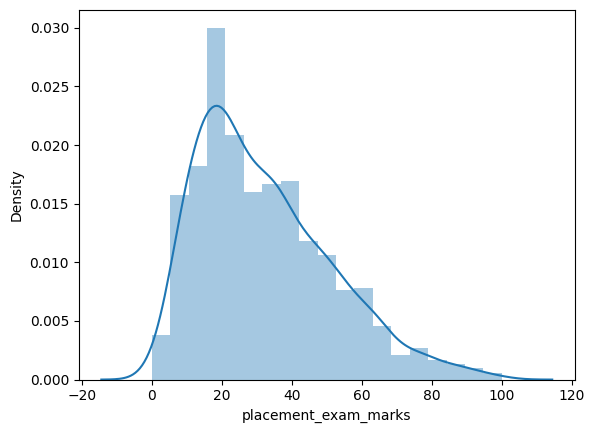

In [22]:
# sns.distplot(df['cgpa'])
sns.distplot(df['placement_exam_marks'])


In [26]:
q1=df['placement_exam_marks'].quantile(0.25)
q3=df['placement_exam_marks'].quantile(0.75)
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
print(f"Min {min} max {max} iqr {iqr} q1:{q1} q3:{q3}")

Min -23.5 max 84.5 iqr 27.0 q1:17.0 q3:44.0


In [37]:
df[(df['placement_exam_marks']<min) | (df['placement_exam_marks']>max)].shape

(15, 3)

<Axes: ylabel='placement_exam_marks'>

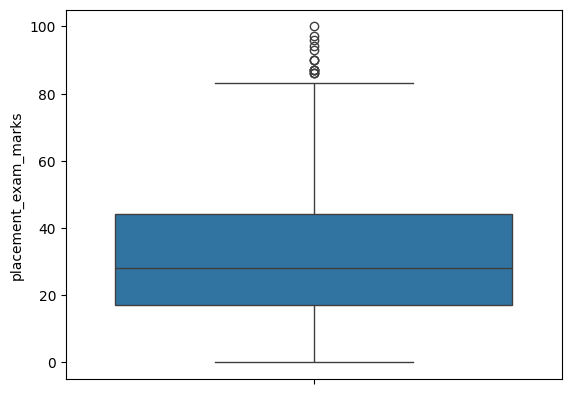

In [38]:
sns.boxplot(df['placement_exam_marks'])

#Trimming


In [43]:
new_df=df[(df['placement_exam_marks']>min) & (df['placement_exam_marks']<max)]

In [44]:
new_df.shape

(985, 3)

In [51]:
new_df[new_df['placement_exam_marks']>max]
new_df['placement_exam_marks'].max()
new_df['placement_exam_marks'].quantile(0.75)+1.5*(new_df['placement_exam_marks'].quantile(0.75)-new_df['placement_exam_marks'].quantile(0.25))

np.float64(82.0)

<Axes: ylabel='placement_exam_marks'>

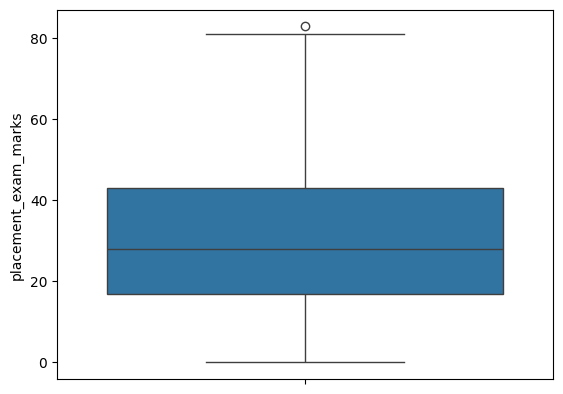

In [47]:
sns.boxplot(new_df['placement_exam_marks'])

In [52]:
df['updated_marks']=np.where(
    df['placement_exam_marks']>max,max,
    np.where(
        df['placement_exam_marks']<min,min,
        df['placement_exam_marks']
    )
)

In [55]:
df['updated_marks'].max()

84.5

In [56]:
df['placement_exam_marks'].max()

100.0

In [57]:
df['updated_marks']

,updated_marks
0,26.0
1,38.0
2,40.0
3,8.0
4,17.0
...,...
995,44.0
996,65.0
997,34.0
998,46.0


<Axes: ylabel='updated_marks'>

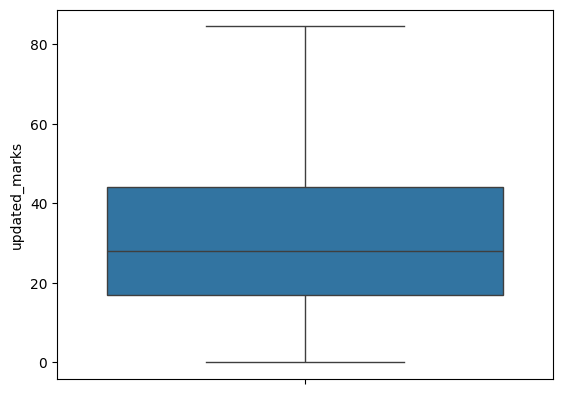

In [59]:
sns.boxplot(df['updated_marks'])